# Breast Cancer Wisconsin Classification Project

Bu projede Breast Cancer Wisconsin veri seti kullanılarak iyi huylu (benign) ve kötü huylu (malignant) tümör sınıflandırması yapılmıştır.

Kullanılan yöntemler:
- Decision Tree (Gini)
- Decision Tree (Entropy)
- max_depth optimizasyonu
- Model karşılaştırması

Amaç:
Breast cancer verileri üzerinde farklı Decision Tree modellerinin performanslarını karşılaştırmak ve overfitting problemini analiz etmek.

## 1. Gerekli Kütüphanelerin Yüklenmesi

Bu bölümde veri analizi, görselleştirme ve makine öğrenmesi işlemleri için gerekli Python kütüphaneleri projeye dahil edildi.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 2. Veri Setinin Yüklenmesi

Scikit-learn içerisindeki Breast Cancer Wisconsin veri seti projeye dahil edildi.

Veri seti:
- 569 örnek içerir
- 30 özellik bulunur
- Çıktı sınıfları:
  - benign
  - malignant

In [ ]:
# Veri setini yükleyelim
data = load_breast_cancer()

# Özellikler (X) ve hedef değişken (y)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Veri Seti:")
print(X.head())

Veri Seti:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0

## 3. Veri Dağılımının İncelenmesi

Bu adımda veri setindeki benign ve malignant sınıflarının dağılımı incelendi.

Amaç:
Veri setinde sınıf dengesizliği olup olmadığını kontrol etmektir.

Sonuç:
Veri setinde benign sınıfı malignant sınıfından daha fazladır.

Sınıf Dağılımı:
benign       357
malignant    212
Name: count, dtype: int64


/tmp/ipykernel_2279/1991175989.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=class_labels, palette="Set2")


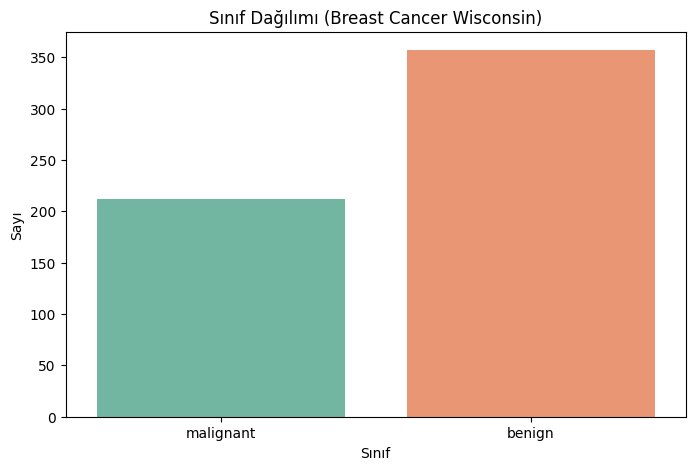

In [ ]:
# Sınıf dağılımını gösterelim
class_labels = pd.Series(data.target).map({
    0: data.target_names[0],
    1: data.target_names[1]
})

print("Sınıf Dağılımı:")
print(class_labels.value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x=class_labels, palette="Set2")
plt.title("Sınıf Dağılımı (Breast Cancer Wisconsin)")
plt.xlabel("Sınıf")
plt.ylabel("Sayı")
plt.show()

## 4. Veriyi Eğitim ve Test Olarak Ayırma

Makine öğrenmesi modelinin performansını değerlendirebilmek için veri seti eğitim ve test olarak ikiye ayrıldı.

- %70 eğitim verisi
- %30 test verisi

Eğitim verisi modeli öğretmek için kullanılırken,
test verisi modelin yeni veriler üzerindeki başarısını ölçmek için kullanılmıştır.

In [ ]:
# Veriyi eğitim ve test olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Eğitim veri seti boyutu:", X_train.shape)
print("Test veri seti boyutu:", X_test.shape)

Eğitim veri seti boyutu: (398, 30)
Test veri seti boyutu: (171, 30)


## 5. Gini Kriteri ile Karar Ağacı Modeli

Bu bölümde Decision Tree modeli Gini kriteri kullanılarak oluşturulmuş ve eğitim verisi ile eğitilmiştir.

Gini kriteri:
Bir düğümdeki safsızlığı ölçer.
Gini değeri ne kadar düşükse sınıflar o kadar iyi ayrılmış demektir.

Gini formülü:

Gini = 1 - Σ(pi²)

Burada:
- pi → her sınıfın olasılığıdır
- Gini değeri 0'a yaklaştıkça düğüm daha saf hale gelir.

In [ ]:
# Gini kriteri ile karar ağacı modelini oluşturalım
model_gini = DecisionTreeClassifier(criterion="gini", random_state=0)

# Modeli eğitelim
model_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

### Gini Modelinin Görselleştirilmesi

Bu bölümde Gini kriteri kullanılarak oluşturulan karar ağacının yapısı görselleştirilmiştir.

Karar ağacı:
- Hangi özelliklerin karar vermede önemli olduğunu
- Veri ayrım noktalarını
- Nihai sınıflandırma sonuçlarını göstermektedir.

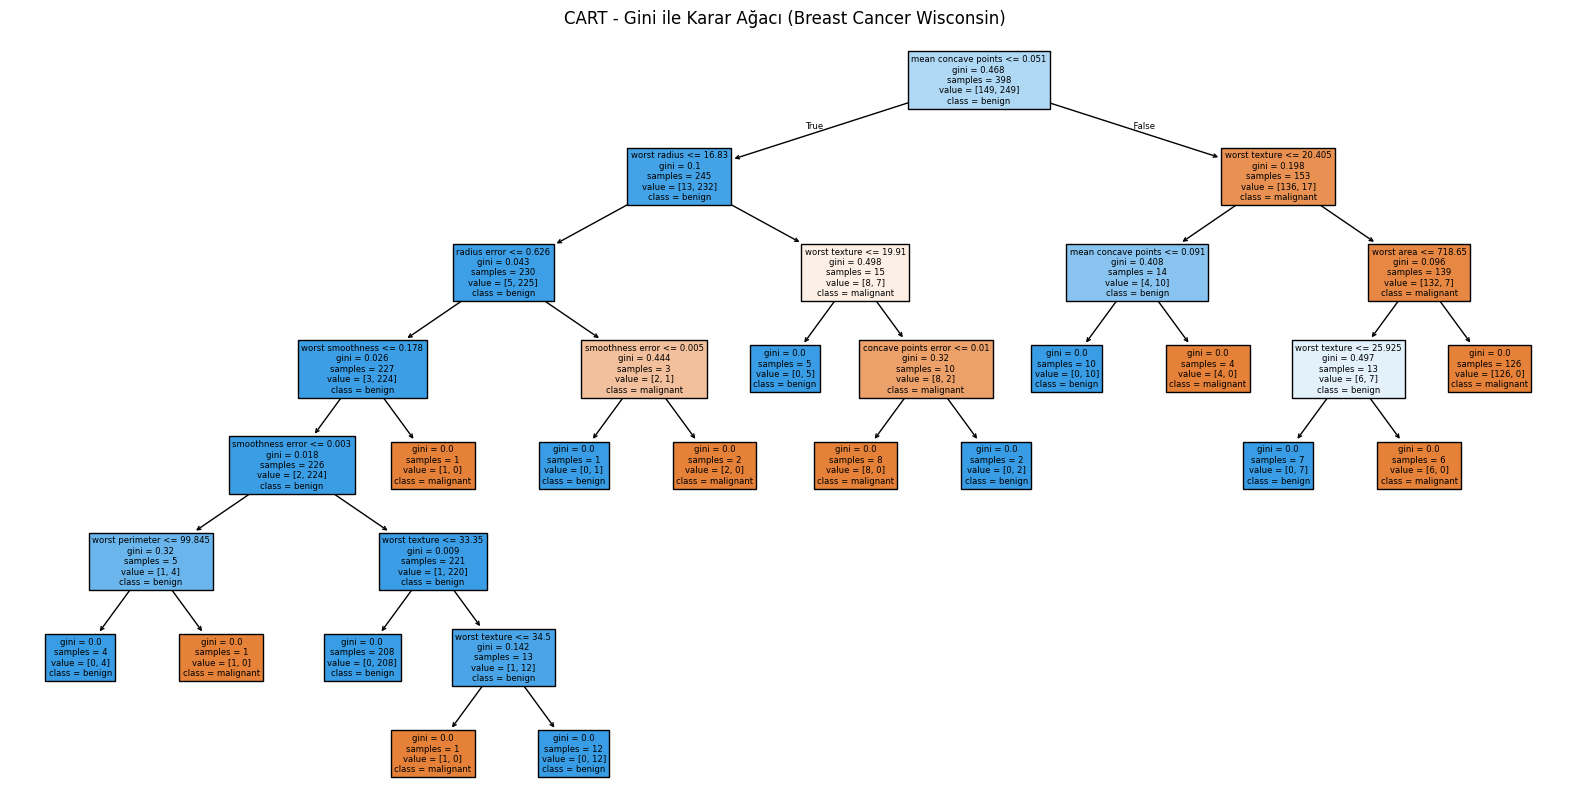

In [ ]:
# Karar ağacını çizdirelim
plt.figure(figsize=(20,10))
plot_tree(
    model_gini,
    filled=True,
    feature_names=X.columns,
    class_names=data.target_names
)
plt.title("CART - Gini ile Karar Ağacı (Breast Cancer Wisconsin)")
plt.show()

## 6. Gini Model Performans Analizi

Bu bölümde Gini kriteri ile oluşturulan karar ağacı modelinin eğitim ve test doğruluk skorları hesaplanmıştır.

Amaç:
Modelin eğitim verisi üzerindeki başarısı ile test verisi üzerindeki genelleme performansını karşılaştırmaktır.

Not:
Eğitim skorunun çok yüksek olması, modelin overfitting yapmış olabileceğini gösterebilir.

In [ ]:
# Modelin doğruluk skorlarını yazdıralım
print("Eğitim Seti Doğruluk Skoru:", model_gini.score(X_train, y_train))
print("Test Seti Doğruluk Skoru:", model_gini.score(X_test, y_test))

Eğitim Seti Doğruluk Skoru: 1.0
Test Seti Doğruluk Skoru: 0.9239766081871345


## 7. Entropy Kriteri ile Karar Ağacı Modeli

Bu bölümde Decision Tree modeli Entropy kriteri kullanılarak oluşturulmuş ve eğitim verisi ile eğitilmiştir.

Entropy kriteri:
Bir düğümdeki belirsizliği ölçer.
Entropy değeri azaldıkça sınıflar daha net ayrılmaktadır.

Entropy formülü:

Entropy = - Σ pi log₂(pi)

Burada:
- pi → her sınıfın olasılığıdır
- Entropy değeri azaldıkça belirsizlik azalır
- Entropy = 0 olduğunda düğüm tamamen saf olur

In [ ]:
# Entropy kriteri ile model oluşturalım
model_entropy = DecisionTreeClassifier(criterion="entropy", random_state=0)

# Modeli eğitelim
model_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
# Entropy modelinin doğruluk skorları
print("Entropy ile Eğitim Skoru:", model_entropy.score(X_train, y_train))
print("Entropy ile Test Skoru:", model_entropy.score(X_test, y_test))

Entropy ile Eğitim Skoru: 1.0
Entropy ile Test Skoru: 0.9590643274853801


In [ ]:
# Sonuçları tablo halinde gösterelim
results = {
    "Model": ["Gini", "Entropy"],
    "Eğitim Skoru": [
        model_gini.score(X_train, y_train),
        model_entropy.score(X_train, y_train)
    ],
    "Test Skoru": [
        model_gini.score(X_test, y_test),
        model_entropy.score(X_test, y_test)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

     Model  Eğitim Skoru  Test Skoru
0     Gini           1.0    0.923977
1  Entropy           1.0    0.959064


## 8. Overfitting Problemini Azaltma (max_depth=3)

İlk modellerde eğitim doğruluğu %100 çıkmıştır.
Bu durum modelin veriyi ezberlediğini ve overfitting yapabileceğini göstermektedir.

Bu problemi azaltmak için karar ağacının derinliği sınırlandırılmıştır:

- max_depth = 3

Amaç:
Daha dengeli ve genellenebilir bir model elde etmektir.

In [ ]:
# Daha kontrollü Gini modeli
model_gini_depth = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=0
)

model_gini_depth.fit(X_train, y_train)

print("max_depth=3 Eğitim Skoru:", model_gini_depth.score(X_train, y_train))
print("max_depth=3 Test Skoru:", model_gini_depth.score(X_test, y_test))

max_depth=3 Eğitim Skoru: 0.9698492462311558
max_depth=3 Test Skoru: 0.9649122807017544


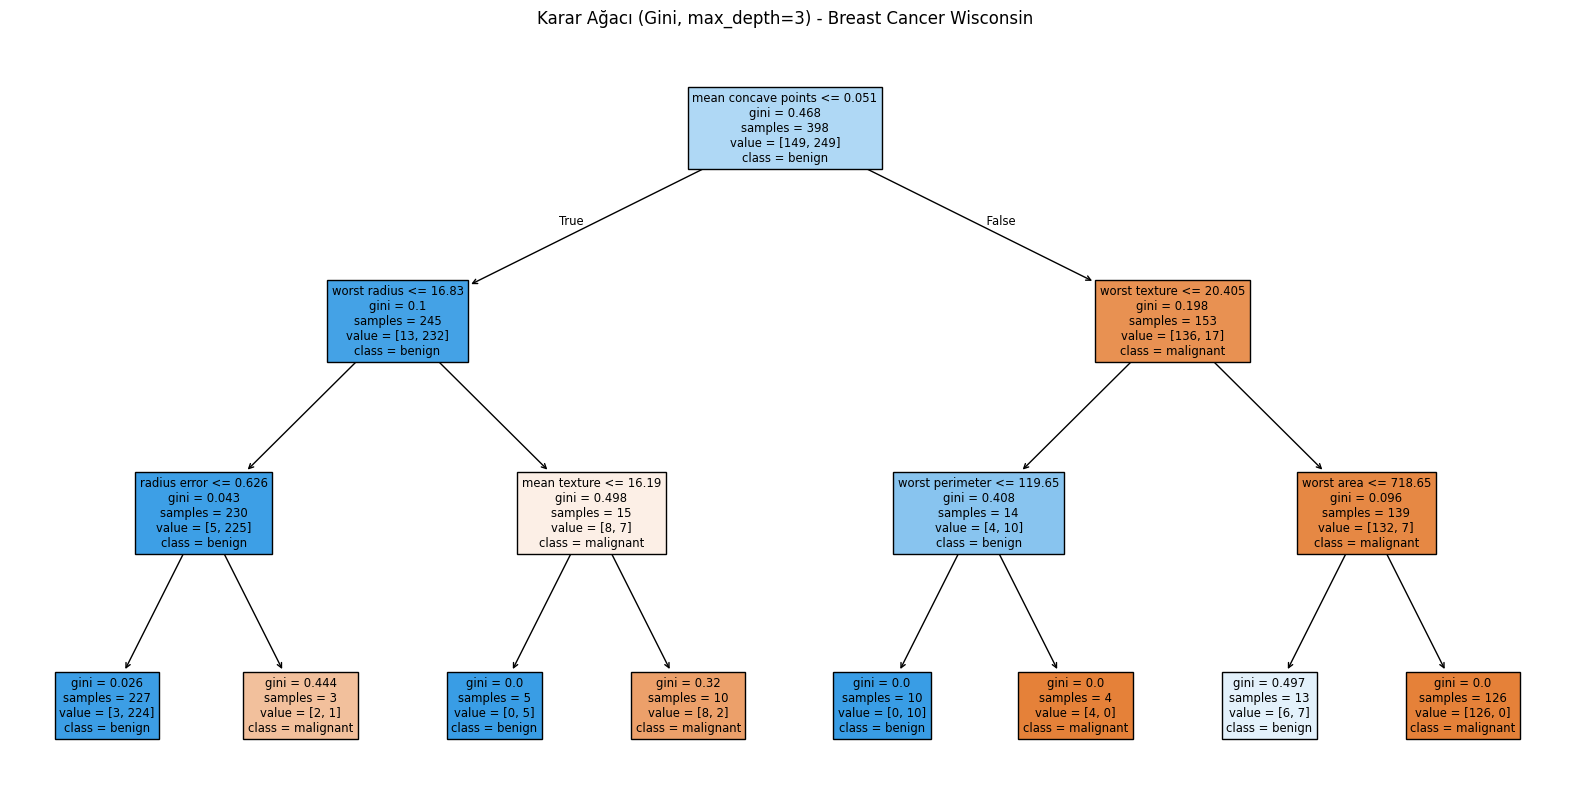

In [ ]:
# max_depth=3 Gini karar ağacını görselleştirelim
plt.figure(figsize=(20,10))
plot_tree(
    model_gini_depth,
    filled=True,
    max_depth=3,
    feature_names=data.feature_names,
    class_names=data.target_names
)
plt.title("Karar Ağacı (Gini, max_depth=3) - Breast Cancer Wisconsin")
plt.show()

## 9. Kontrollü Entropy Modeli

Bu bölümde Entropy tabanlı karar ağacı modeli için de aynı overfitting problemi azaltılmaya çalışılmıştır.

Karar ağacının derinliği tekrar sınırlandırılmıştır:

- max_depth = 3

Amaç:
Gini ve Entropy modellerini aynı koşullarda karşılaştırabilmektir.

In [ ]:
# max_depth=3 Entropy modeli oluşturalım
model_entropy_depth = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=0
)

# Modeli eğitelim
model_entropy_depth.fit(X_train, y_train)

# Skorları yazdıralım
print("Entropy max_depth=3 Eğitim Skoru:", model_entropy_depth.score(X_train, y_train))
print("Entropy max_depth=3 Test Skoru:", model_entropy_depth.score(X_test, y_test))

Entropy max_depth=3 Eğitim Skoru: 0.9798994974874372
Entropy max_depth=3 Test Skoru: 0.9649122807017544


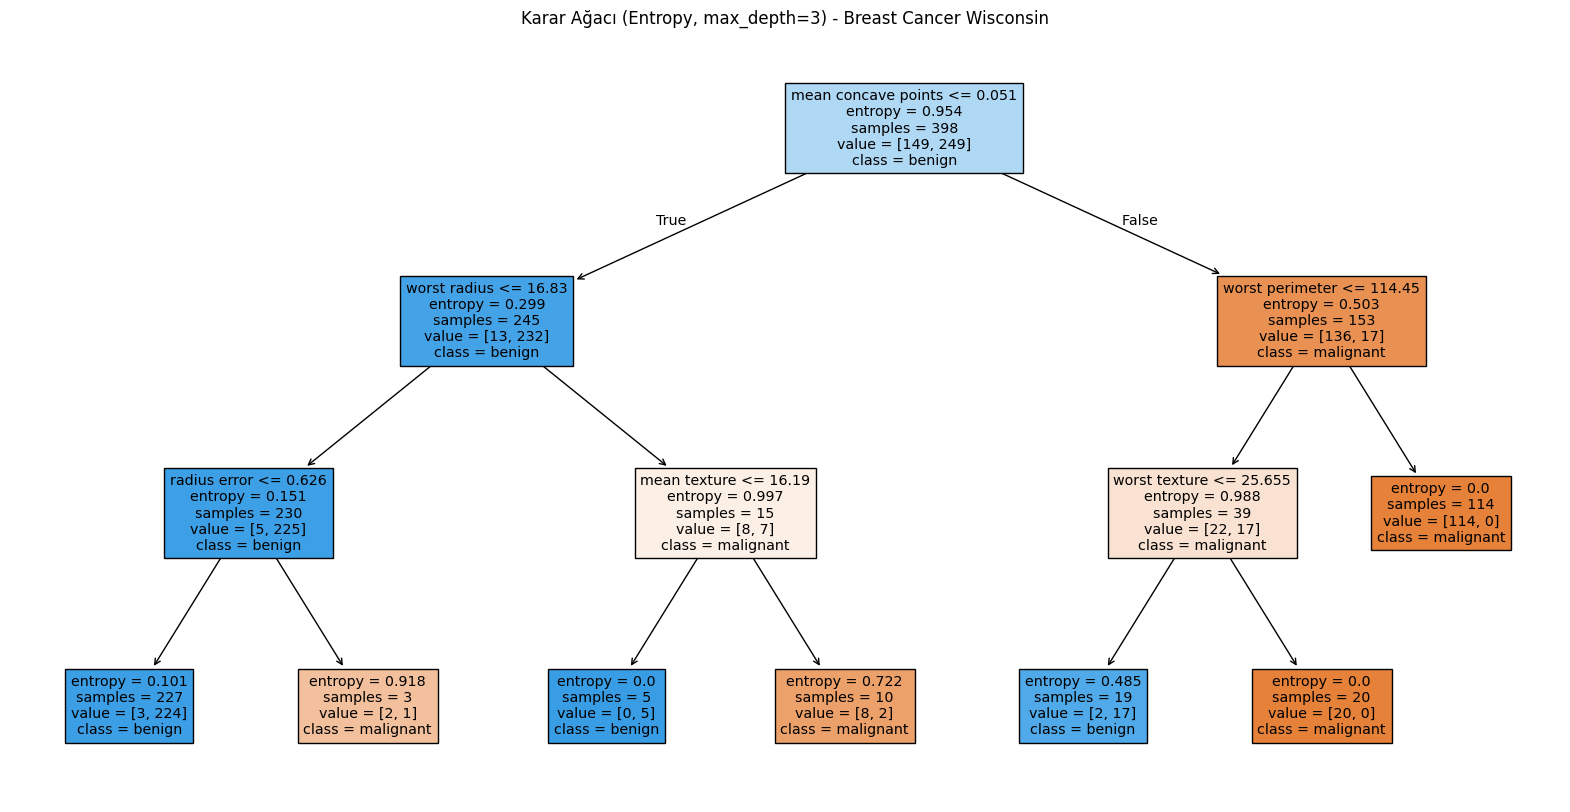

In [ ]:
# max_depth=3 Entropy karar ağacını görselleştirelim
plt.figure(figsize=(20,10))
plot_tree(
    model_entropy_depth,
    filled=True,
    max_depth=3,
    feature_names=data.feature_names,
    class_names=data.target_names
)
plt.title("Karar Ağacı (Entropy, max_depth=3) - Breast Cancer Wisconsin")
plt.show()

## 10. Tüm Modellerin Karşılaştırılması

Bu bölümde oluşturulan tüm karar ağacı modellerinin eğitim ve test skorları birlikte değerlendirilmiştir.

Karşılaştırılan modeller:
- Gini
- Entropy
- Gini (max_depth=3)
- Entropy (max_depth=3)

Amaç:
En dengeli ve en iyi genelleme yapan modeli belirlemektir.

In [ ]:
# Tüm modelleri karşılaştıralım
results = {
    "Model": [
        "Gini",
        "Entropy",
        "Gini max_depth=3",
        "Entropy max_depth=3"
    ],

    "Eğitim Skoru": [
        model_gini.score(X_train, y_train),
        model_entropy.score(X_train, y_train),
        model_gini_depth.score(X_train, y_train),
        model_entropy_depth.score(X_train, y_train)
    ],

    "Test Skoru": [
        model_gini.score(X_test, y_test),
        model_entropy.score(X_test, y_test),
        model_gini_depth.score(X_test, y_test),
        model_entropy_depth.score(X_test, y_test)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Eğitim Skoru  Test Skoru
0                 Gini      1.000000    0.923977
1              Entropy      1.000000    0.959064
2     Gini max_depth=3      0.969849    0.964912
3  Entropy max_depth=3      0.979899    0.964912


## 11. Sonuç

Bu projede Breast Cancer Wisconsin veri seti üzerinde farklı Decision Tree modelleri karşılaştırılmıştır.

Elde edilen sonuçlar:

- Gini test skoru: 0.923
- Entropy test skoru: 0.959
- Gini (max_depth=3) test skoru: 0.964
- Entropy (max_depth=3) test skoru: 0.964

Analiz sonucu:

- İlk modellerde eğitim başarısı %100 olduğu için overfitting riski gözlemlenmiştir.
- max_depth kullanımı modelin daha dengeli çalışmasını sağlamıştır.
- En başarılı modeller kontrollü Gini ve kontrollü Entropy modelleri olmuştur.

Bu proje, karar ağacı algoritmalarında model karmaşıklığının kontrol edilmesinin performans açısından önemli olduğunu göstermektedir.